In [ ]:
# @title
#assuming perfect knowledge of both velocities
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pygame
import random

class Vanguard1D(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super(Vanguard1D, self).__init__()

        # --- Constants ---
        self.target_dist = 1.2  # We want to be 1.2m away
        self.dt = 0.1           # 10Hz Decision Frequency
        self.max_accel = 2.5    # Stroller can't accelerate faster than 2m/s^2
        self.render_mode = render_mode
        self.window = None      # For Pygame
        self.clock = None

        # --- Spaces ---
        # Action: Continuous value [-1, 1] which we scale to [-2, 2]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        # Observation: [Dist_Error, Stroller_Vel, Person_Vel]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32)

        # Initialize state variables to avoid attribute errors
        self.person_pos = 0.0
        self.person_vel = 0.0
        self.stroller_pos = 0.0
        self.stroller_vel = 0.0
        self.step_count = 0

    def reset(self, seed=None, options=None):
        # 1. Seeding
        super().reset(seed=seed)

        # 2. Reset Physics State
        self.person_pos = 0.0
        self.person_vel = 1.0 # Start walking at 1m/s

        self.stroller_pos = self.target_dist # Start perfectly at distance d
        self.stroller_vel = 0.0

        self.step_count = 0

        # 3. Create First Observation
        dist_error = (self.stroller_pos - self.person_pos) - self.target_dist
        observation = np.array(
            [dist_error, self.stroller_vel, self.person_vel],
            dtype=np.float32
        )

        # 4. Info Dict
        info = {}

        # 5. Render Initial Frame
        if self.render_mode == "human":
            self.render()

        # 6. RETURN (Must be indented to match 'def reset')
        return observation, info

    def step(self, action):
        self.step_count += 1

        # 1. Unpack Action
        stroller_accel = float(action[0]) * self.max_accel

        # 2. Update Person (Bounded Random Walk Physics)
        accel_noise = random.uniform(-0.4, 0.4)
        self.person_vel = np.clip(self.person_vel + accel_noise, -2.0, 2.0)
        #self.person_vel = 1.0
        self.person_pos += self.person_vel * self.dt

        # 3. Update Stroller (Physics)
        self.stroller_vel += stroller_accel * self.dt
        self.stroller_pos += self.stroller_vel * self.dt

        # 4. Calculate Stats
        actual_dist = self.stroller_pos - self.person_pos
        error = actual_dist - self.target_dist

        # 5. Reward Function
        reward = 0.0
        reward -= (error ** 2)              # Accuracy
        reward -= 0.1 * (stroller_accel ** 2) # Smoothness

        terminated = False
        if actual_dist < 0.2: # Collision
            reward -= 100.0
            terminated = True
        if actual_dist > 4.0: # Lost track
            reward -= 100.0
            terminated = True

        truncated = False
        if self.step_count > 500:
            truncated = True

        # 6. Return Package
        observation = np.array([error, self.stroller_vel, self.person_vel], dtype=np.float32)
        info = {}

        if self.render_mode == "human":
            self.render()

        return observation, reward, terminated, truncated, info

    def render(self):
        if self.window is None:
            pygame.init()
            pygame.display.init()
            self.window = pygame.display.set_mode((800, 200))
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((800, 200))
        canvas.fill((255, 255, 255))

        scale = 100.0
        offset_x = 100

        # Draw Person (Blue Circle)
        p_x = int(self.person_pos * scale) + offset_x
        pygame.draw.circle(canvas, (0, 0, 255), (p_x, 100), 15)

        # Draw Target Distance (Green Line)
        target_x = int((self.person_pos + self.target_dist) * scale) + offset_x
        pygame.draw.line(canvas, (0, 255, 0), (target_x, 50), (target_x, 150), 3)

        # Draw Stroller (Red Rect)
        s_x = int(self.stroller_pos * scale) + offset_x
        pygame.draw.rect(canvas, (255, 0, 0), pygame.Rect(s_x - 10, 90, 20, 20))

        self.window.blit(canvas, (0, 0))
        pygame.event.pump()
        pygame.display.update()
        self.clock.tick(self.metadata["render_fps"])

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

In [ ]:
import gymnasium as gym
from gymnasium import spaces
# FIX 1: Import the correct new wrapper names
from gymnasium.wrappers import FrameStackObservation, FlattenObservation
import numpy as np
import pygame
import random

class Vanguard1D(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super(Vanguard1D, self).__init__()

        # --- Constants ---
        self.target_dist = 1.2
        self.dt = 0.1
        self.max_accel = 10.0
        self.render_mode = render_mode
        self.window = None
        self.clock = None

        # --- Spaces ---
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        # Observation: Just [Dist_Error, Stroller_Vel] (Shape 2)
        # The wrappers will expand this to Shape 8 later.
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32)

        self.person_pos = 0.0
        self.person_vel = 0.0
        self.stroller_pos = 0.0
        self.stroller_vel = 0.0
        self.step_count = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.person_pos = 0.0
        self.person_vel = 1.0
        self.stroller_pos = self.target_dist
        self.stroller_vel = 0.0
        self.step_count = 0

        dist_error = (self.stroller_pos - self.person_pos) - self.target_dist

        # Observation is only 2 values now
        observation = np.array([dist_error, self.stroller_vel], dtype=np.float32)

        info = {}
        if self.render_mode == "human":
            self.render()
        return observation, info

    def step(self, action):
        self.step_count += 1

        # Physics
        stroller_accel = float(action[0]) * self.max_accel

        accel_noise = random.uniform(-0.4, 0.4)
        self.person_vel = np.clip(self.person_vel + accel_noise, -2.0, 2.0)
        self.person_pos += self.person_vel * self.dt

        self.stroller_vel += stroller_accel * self.dt
        self.stroller_pos += self.stroller_vel * self.dt

        # Stats
        actual_dist = self.stroller_pos - self.person_pos
        error = actual_dist - self.target_dist

        # Reward
        reward = 0.0
        reward -= (error ** 2)
        reward -= 0.1 * (stroller_accel ** 2)

        terminated = False
        if actual_dist < 0.2: reward -= 100.0; terminated = True
        if actual_dist > 4.0: reward -= 100.0; terminated = True
        truncated = (self.step_count > 500)

        observation = np.array([error, self.stroller_vel], dtype=np.float32)

        info = {}
        if self.render_mode == "human":
            self.render()

        return observation, reward, terminated, truncated, info

    def render(self):
        if self.window is None:
            pygame.init()
            pygame.display.init()
            self.window = pygame.display.set_mode((800, 200))
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((800, 200))
        canvas.fill((255, 255, 255))
        scale = 100.0
        offset_x = 100

        p_x = int(self.person_pos * scale) + offset_x
        pygame.draw.circle(canvas, (0, 0, 255), (p_x, 100), 15)

        target_x = int((self.person_pos + self.target_dist) * scale) + offset_x
        pygame.draw.line(canvas, (0, 255, 0), (target_x, 50), (target_x, 150), 3)

        s_x = int(self.stroller_pos * scale) + offset_x
        pygame.draw.rect(canvas, (255, 0, 0), pygame.Rect(s_x - 10, 90, 20, 20))

        self.window.blit(canvas, (0, 0))
        pygame.event.pump()
        pygame.display.update()
        self.clock.tick(self.metadata["render_fps"])

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

# --- THE FIX: Updated Wrapper Function ---
def make_vanguard_env(render_mode=None):
    # 1. Create Base Env
    env = Vanguard1D(render_mode=render_mode)

    # 2. Stack the last 4 frames using the NEW class name
    # 'stack_size' replaces 'num_stack' in Gymnasium v1.0
    env = FrameStackObservation(env, stack_size=10)

    # 3. Flatten it
    env = FlattenObservation(env)

    return env

# Check if it works
if __name__ == "__main__":
    env = make_vanguard_env()
    print("Wrapped Observation Space:", env.observation_space.shape)
    obs, _ = env.reset()
    print("Initial Observation Shape:", obs.shape)

Wrapped Observation Space: (20,)
Initial Observation Shape: (20,)


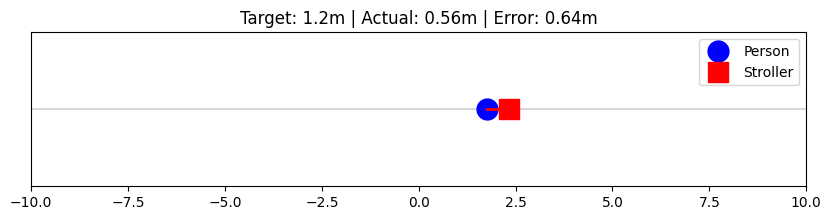

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import time

# 1. Setup
env = Vanguard1D(render_mode=None) # We handle rendering manually
obs, _ = env.reset()

# 2. Simulation Loop
try:
    for step in range(100): # Run for 100 frames (10 seconds)

        # --- LOGIC ---
        action = env.action_space.sample() # Random action
        obs, reward, terminated, truncated, info = env.step(action)

        # --- VISUALIZATION (Matplotlib) ---
        clear_output(wait=True) # Clear previous frame

        fig, ax = plt.subplots(figsize=(10, 2))

        # A. The Track (0m to 10m)
        ax.set_xlim(-10, 10)
        ax.set_ylim(0, 2)
        ax.set_yticks([]) # Hide Y axis
        ax.axhline(y=1, color='gray', linestyle='-', alpha=0.3) # The "Floor"

        # B. The Person (Blue Dot)
        # We access env variables directly
        p_pos = env.person_pos
        ax.plot(p_pos, 1, 'bo', markersize=15, label='Person')

        # C. The Stroller (Red Square)
        s_pos = env.stroller_pos
        ax.plot(s_pos, 1, 'rs', markersize=15, label='Stroller')

        # D. The "Tether" (Line connecting them)
        # Color logic: Green if close to target (1.2m), Red if far
        dist = s_pos - p_pos
        err = abs(dist - env.target_dist)
        tether_color = 'green' if err < 0.2 else 'red'

        ax.plot([p_pos, s_pos], [1, 1], color=tether_color, linewidth=2)

        # E. HUD Text
        info_str = f"Target: {env.target_dist}m | Actual: {dist:.2f}m | Error: {err:.2f}m"
        ax.set_title(info_str)
        ax.legend(loc='upper right')

        plt.show()

        # F. Reset if crashed
        if terminated or truncated:
            obs, _ = env.reset()

except KeyboardInterrupt:
    print("Stopped.")

In [ ]:
from stable_baselines3 import PPO
import os

# 1. Create the Environment (No rendering during training for speed)
env = Vanguard1D(render_mode=None)

# 2. Initialize PPO
# "MlpPolicy" = Standard Neural Network (Input -> Layers -> Output)
# verbose=1 shows you the progress log
model = PPO("MlpPolicy", env, verbose=1)

print("Training Started... (This will take about 30-60 seconds)")

# 3. Train
# 15,000 steps is usually enough for this simple 1D physics
model.learn(total_timesteps=100000)

print("Training Complete!")
model.save("vanguard_1d_ppo")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training Started... (This will take about 30-60 seconds)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 12.9     |
|    ep_rew_mean     | -179     |
| time/              |          |
|    fps             | 1428     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 15.7         |
|    ep_rew_mean          | -195         |
| time/                   |              |
|    fps                  | 973          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0043133767 |
|    clip_fraction        | 0.0256       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.39        |
|    explained_variance   | 0.0152       |
|    learning_r

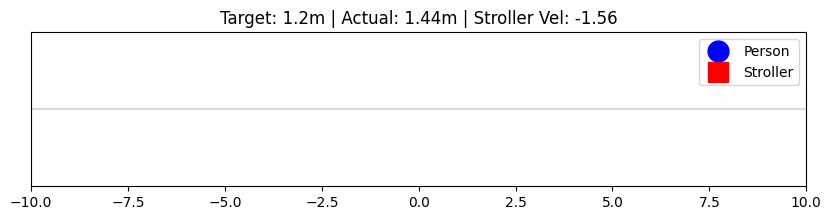

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import time

# 1. Load the Environment & Model
env = Vanguard1D(render_mode=None)
# We use the model object we just trained.
# If you restarted the kernel, use: model = PPO.load("vanguard_1d_ppo")

obs, _ = env.reset()

print("Starting Smart Simulation...")

try:
    for step in range(200): # Run for 20 seconds

        # --- THE BRAIN ---
        # deterministic=True means "Do the best move you know" (No random exploring)
        action, _states = model.predict(obs, deterministic=True)

        # Step the environment
        obs, reward, terminated, truncated, info = env.step(action)

        # --- VISUALIZATION ---
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(10, 2))
        ax.set_xlim(-10, 10) # Slightly wider view
        ax.set_ylim(0, 2)
        ax.set_yticks([])
        ax.axhline(y=1, color='gray', linestyle='-', alpha=0.3)

        # Draw Person (Blue) & Stroller (Red)
        p_pos = env.person_pos
        s_pos = env.stroller_pos

        ax.plot(p_pos, 1, 'bo', markersize=15, label='Person')
        ax.plot(s_pos, 1, 'rs', markersize=15, label='Stroller')

        # Draw Tether
        dist = s_pos - p_pos
        err = abs(dist - env.target_dist)
        # Color Logic: Green=Good, Yellow=Warning, Red=Bad
        if err < 0.2: color = 'green'
        elif err < 0.6: color = 'orange'
        else: color = 'red'

        ax.plot([p_pos, s_pos], [1, 1], color=color, linewidth=3)

        # HUD
        ax.set_title(f"Target: {env.target_dist}m | Actual: {dist:.2f}m | Stroller Vel: {env.stroller_vel:.2f}")
        ax.legend(loc='upper right')

        plt.show()

        if terminated or truncated:
            obs, _ = env.reset()

except KeyboardInterrupt:
    print("Stopped.")